# Day 1 · SciPy

**Block:** SciPy (30 min, including slides and live coding)

Filtering a signal is the job most of you will hand to SciPy first.

1. **Filtering with the FFT** (10 min): after SPL Exercise 42, find the mains
   hum in the LFP's spectrum and remove it
2. **Filtering with `scipy.signal`** (10 min): the same job with a notch
   filter, then a band-pass filter on one channel and on all 384 at once
3. **Stretch:** a smoother spectrum with Welch's method, which distribution
   fits the response times (after SPL Exercise 41), and 2-D minimisation (SPL
   Exercise 40)

We keep using the recording from the NumPy block. The exercises are adapted
from [Scientific Python Lectures, SciPy: high-level scientific
computing](https://lectures.scientific-python.org/intro/scipy/index.html) (CC
BY 4.0), which cleans up a photograph instead.

Before writing your own algorithm, **check whether SciPy already has it**.
The [API reference](https://docs.scipy.org/doc/scipy/reference/) lists every submodule.

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

with h5py.File("../data/ibl_session.h5") as f:
    rt = f["trials/response_time_s"][:]
    lfp_uv = f["lfp/data"][:] * f["lfp"].attrs["uV_per_count"]
    sampling_rate = f["lfp"].attrs["sampling_rate_Hz"]

trace = lfp_uv[:, 200]
time = np.arange(trace.size) / sampling_rate

## 1. Filtering with the FFT (after SPL Exercise 42)

The recording was made in the United States, where mains electricity
alternates at **60 Hz**. Every cable in the room radiates it, and some ends up
in the LFP. Remove it from `trace` (channel 200, in µV) with the Fast Fourier
Transform. The cell below gives you three things to start from:

* `spectrum`: the FFT of `trace`, from `sp.fft.rfft` (the FFT for real signals)
* `freqs`: the frequency of each component of `spectrum`, in Hz, from `sp.fft.rfftfreq`
* `hum`: a mask on `freqs`, `True` within 1 Hz of 60 Hz **and of its
  harmonics**, 120 and 180 Hz

1. Plot the first 0.5 s of `trace` against `time`.
2. Plot the spectrum (the absolute value) against `freqs`. Is it hard to see
   anything? Why? (Hint: `ax.set_yscale("log")`.) Where is the mains hum?
3. Make a copy of `spectrum` called `filtered`, and set the components selected
   by `hum` to zero.
4. Apply the inverse FFT (`irfft`, with `n=` the length of `trace`) to get
   `cleaned`, and plot what you **removed**, `trace - cleaned`, for the first
   0.2 s. What does it look like?

In [ ]:
# The spectrum of `trace`, and the frequency (Hz) of each component
spectrum = sp.fft.rfft(trace)
freqs = sp.fft.rfftfreq(trace.size, d=1 / sampling_rate)

# True within 1 Hz of the mains hum (60 Hz) and its harmonics (120 and 180 Hz)
hum = (np.abs(freqs - 60) < 1) | (np.abs(freqs - 120) < 1) | (np.abs(freqs - 180) < 1)

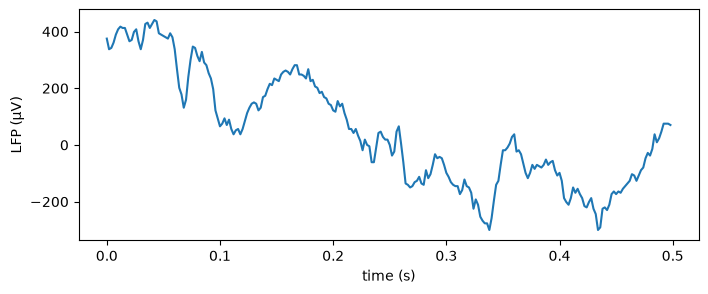

In [2]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time[:250], trace[:250])
ax.set_xlabel("time (s)")
ax.set_ylabel("LFP (µV)");

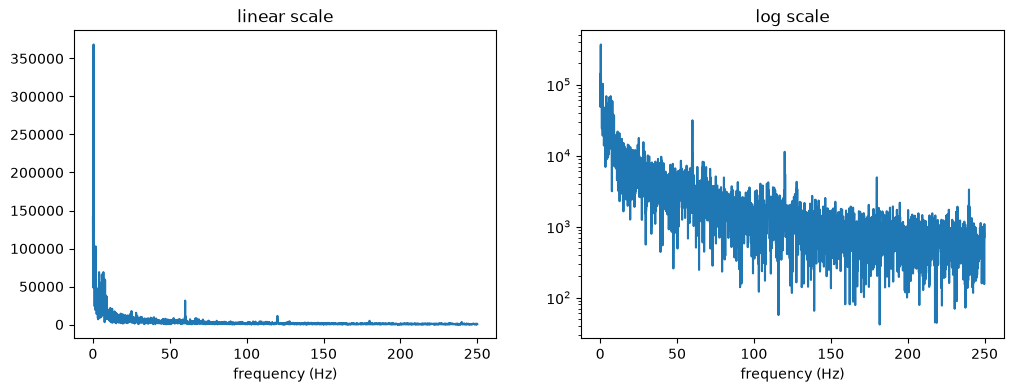

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(freqs, np.abs(spectrum))
axes[0].set_title("linear scale")
axes[1].plot(freqs, np.abs(spectrum))
axes[1].set_yscale("log")
axes[1].set_title("log scale")
for ax in axes:
    ax.set_xlabel("frequency (Hz)")

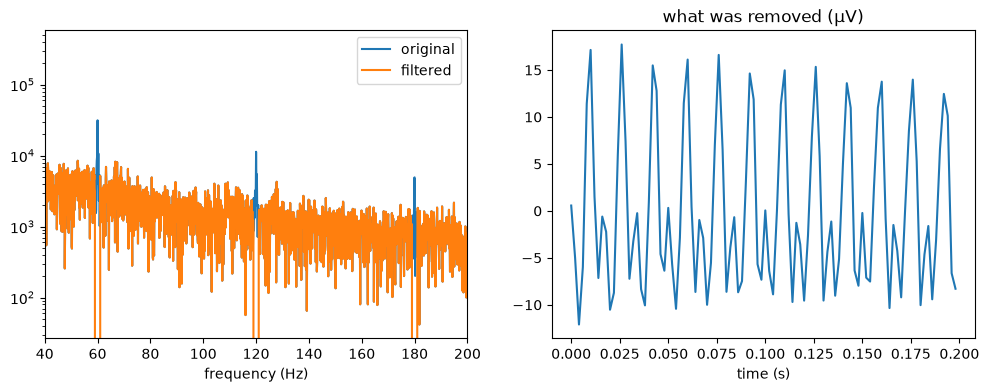

In [6]:
filtered = spectrum.copy()
filtered[hum] = 0
cleaned = sp.fft.irfft(filtered, n=trace.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(freqs, np.abs(spectrum), label="original")
axes[0].plot(freqs, np.abs(filtered), label="filtered")
axes[0].set_yscale("log")
axes[0].set_xlim(40, 200)
axes[0].set_xlabel("frequency (Hz)")
axes[0].legend()
axes[1].plot(time[:100], (trace - cleaned)[:100])
axes[1].set_xlabel("time (s)")
axes[1].set_title("what was removed (µV)");

On a linear scale the slow frequencies, below a few hertz, dominate (the LFP is
mostly slow waves) and everything else looks flat. On a log scale the spectrum
falls steadily with frequency, with sharp spikes at 60, 120 and 180 Hz: the
mains hum and its harmonics. The FFT of a real signal is symmetric, so `rfft`
keeps only the positive frequencies, up to half the sampling rate (250 Hz).

What was removed repeats 12 times in 0.2 s: 60 Hz, as expected, peaking at
about 15 µV. Each cycle has a second, smaller bump: that is the 120 Hz
harmonic. Zeroing FFT bins like this is a crude **notch filter**: fine for a
quick look, but it can ring at the edges of the recording, and it needs the
whole recording in memory at once.

## 2. Filtering with `scipy.signal`

In practice you would design a filter with `sp.signal` and apply it. Filters
come as coefficients: `b, a` for short ones, or `sos` ("second-order
sections"), which is numerically safer for longer ones. `filtfilt` and
`sosfiltfilt` run the filter forwards and then backwards, so the filtered
signal is not delayed relative to the original.

1. Design a 60 Hz notch filter with `b, a = sp.signal.iirnotch(60, Q=30,
   fs=sampling_rate)` and apply it to `trace` with `sp.signal.filtfilt` to
   get `notched`. Plot what it removed, `trace - notched`, for the first
   0.2 s, on the same axes as what the FFT removed. How do they differ?
2. The slow waves of the LFP sit below about 30 Hz. Design a 4th-order
   Butterworth **band-pass** filter from 1 to 30 Hz with
   `sp.signal.butter(4, [1, 30], btype="bandpass", fs=sampling_rate,
   output="sos")`, and apply it with `sp.signal.sosfiltfilt` to get `slow`.
   Plot `trace` and `slow` for the first 2 s.
3. Filter **every channel** of `lfp_uv` at once, with no loop, to get
   `lfp_slow`, shape (5000, 384). (Hint: which `axis` is time?)

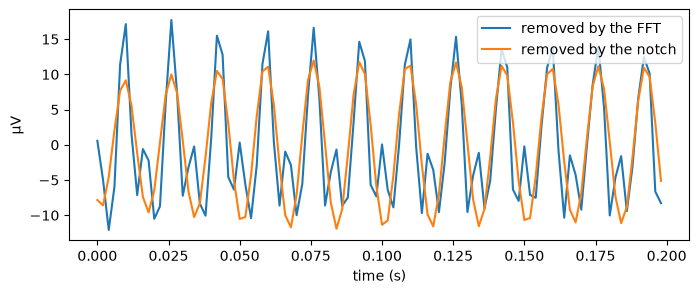

In [7]:
b, a = sp.signal.iirnotch(60, Q=30, fs=sampling_rate)
notched = sp.signal.filtfilt(b, a, trace)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time[:100], (trace - cleaned)[:100], label="removed by the FFT")
ax.plot(time[:100], (trace - notched)[:100], label="removed by the notch")
ax.set_xlabel("time (s)")
ax.set_ylabel("µV")
ax.legend();

The notch only removes 60 Hz, so what it took out is a clean sine wave, without
the 120 Hz bump the FFT version had. For the harmonics, design one notch per
frequency and apply them one after another.

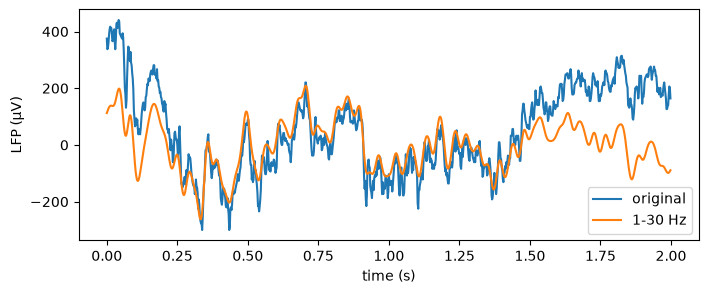

In [8]:
sos = sp.signal.butter(4, [1, 30], btype="bandpass", fs=sampling_rate, output="sos")
slow = sp.signal.sosfiltfilt(sos, trace)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time[:1000], trace[:1000], label="original")
ax.plot(time[:1000], slow[:1000], label="1-30 Hz")
ax.set_xlabel("time (s)")
ax.set_ylabel("LFP (µV)")
ax.legend();

In [ ]:
lfp_slow = sp.signal.sosfiltfilt(sos, lfp_uv, axis=0)
lfp_slow.shape

The band-pass removes the slowest drift (below 1 Hz) as well as the fast
jitter, so `slow` wobbles around 0 while the original wanders. Most SciPy
functions that work on signals take an `axis`, so one call filters all 384
channels; a Python loop over the channels would be slower and longer.

## 3. Stretch

### A smoother spectrum: Welch's method

The FFT of the whole recording is noisy: every frequency gets one estimate.
`sp.signal.welch` cuts the signal into overlapping segments, takes the
spectrum of each and averages them. Compute the power spectra of `trace` and
of `notched` with `sp.signal.welch(..., fs=sampling_rate, nperseg=1000)`
(2 s segments, so 0.5 Hz resolution), and plot both on a log scale. Did the
notch remove the 60 Hz peak? What about 120 and 180 Hz?

In [ ]:
f_welch, power_original = sp.signal.welch(trace, fs=sampling_rate, nperseg=1000)
_, power_notched = sp.signal.welch(notched, fs=sampling_rate, nperseg=1000)

fig, ax = plt.subplots()
ax.plot(f_welch, power_original, label="original")
ax.plot(f_welch, power_notched, label="60 Hz notch")
ax.set_yscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("power (µV²/Hz)")
ax.legend();

The averaged spectrum is far smoother, which makes the peaks easy to see. The
60 Hz peak is gone after the notch, leaving a narrow dip where the filter
also took out a little of the LFP itself; the 120 and 180 Hz harmonics are
still there.

### Which distribution fits the response times? (after SPL Exercise 41)

Response times are positive and skewed, with a long tail. Take the response
times below 5 s (a few much slower trials would stretch the plot). Fit
a gamma distribution and a lognormal distribution to them with
`sp.stats.gamma.fit` and `sp.stats.lognorm.fit`, fixing the location at 0
(`floc=0`). Plot their PDFs on top of the histogram (`ax.hist(...,
density=True)`). Which fits better? Compare the total log-likelihood,
`dist.logpdf(sample, *params).sum()`, too: higher is better.

Extra: use the better fit's `.ppf` to find the response time that 90% of
trials beat.

In [ ]:
sample = rt[rt < 5]
params_gamma = sp.stats.gamma.fit(sample, floc=0)
params_lognorm = sp.stats.lognorm.fit(sample, floc=0)

x = np.linspace(0.01, 2, 300)
fig, ax = plt.subplots()
ax.hist(sample, bins=np.linspace(0, 2, 60), density=True, alpha=0.5, label="response times")
ax.plot(x, sp.stats.gamma.pdf(x, *params_gamma), label="gamma")
ax.plot(x, sp.stats.lognorm.pdf(x, *params_lognorm), label="lognormal")
ax.set_xlabel("response time (s)")
ax.legend()

for name, dist, params in [("gamma", sp.stats.gamma, params_gamma), ("lognormal", sp.stats.lognorm, params_lognorm)]:
    print(f"{name:10} log-likelihood {dist.logpdf(sample, *params).sum():.1f}")
print(f"90% of responses are faster than {sp.stats.lognorm.ppf(0.9, *params_lognorm):.2f} s")

The lognormal fits much better: it has the sharp peak around 0.3 s and the long
tail, and its log-likelihood is about 110 higher. A lognormal means that the
**logarithm** of the response time is normally distributed, which is why a
log scale suits these data when you plot them on Day 2.

### 2-D minimisation (SPL Exercise 40)

The six-hump camelback function

$$f(x, y) = (4 - 2.1x^2 + \tfrac{x^4}{3})x^2 + xy + (4y^2 - 4)y^2$$

has several local minima. Find a global minimum (there are two, with the same
value) and at least one other local minimum.

* Restrict the search to $-2 < x < 2$ and $-1 < y < 1$.
* Visualise it with `np.meshgrid` and `ax.imshow`.
* Try `sp.optimize.minimize` from (0, 0), then from other starting points. Does
  it find the global minimum?
* Try `sp.optimize.differential_evolution`.

In [ ]:
def sixhump(x):
    return (
        (4 - 2.1 * x[0] ** 2 + x[0] ** 4 / 3) * x[0] ** 2
        + x[0] * x[1]
        + (-4 + 4 * x[1] ** 2) * x[1] ** 2
    )

In [ ]:
xlim, ylim = [-2, 2], [-1, 1]
xg, yg = np.meshgrid(np.linspace(*xlim, 200), np.linspace(*ylim, 100))

res_local = sp.optimize.minimize(sixhump, x0=[0, 0])
res_global = sp.optimize.differential_evolution(sixhump, bounds=[xlim, ylim], seed=0)
print("minimize from (0, 0):", res_local.x.round(3), res_local.fun.round(3))
print("differential_evolution:", res_global.x.round(3), res_global.fun.round(3))

fig, ax = plt.subplots()
img = ax.imshow(sixhump([xg, yg]), extent=xlim + ylim, origin="lower")
fig.colorbar(img, ax=ax)
ax.scatter(*res_local.x, label="minimize from (0, 0)")
ax.scatter(*res_global.x, label="differential_evolution")
ax.legend();

Starting at (0, 0), which is a saddle point with zero gradient, `minimize` does
not move at all. Starting elsewhere, it slides into whichever basin is nearest. A
global method such as `differential_evolution` finds one of the two global minima
at about (±0.09, ∓0.71), where f = -1.03.